# Spotify Tracks Dataset — Regression Analysis
## CC105 Final Project

**Name:** Renz David D. Espiritu

**Section:** BSCS 2A

In [4]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


## 1. Data Loading

We begin by loading the dataset and taking a first look at its structure.

In [5]:
df = pd.read_csv('dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


The dataset contains **114,000+ rows and 21 columns**. Each row represents a unique track, and each column represents either an identifier (like track name or artist) or an audio feature (like energy, tempo, or danceability).


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [7]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

There is one missing value, particularly in columns like `track_name` and `artists`. Since these are identifier columns and not used as features, we can safely drop that one row where columns have nulls.

In [ ]:
# Drop rows with missing values in key columns
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (113999, 21)


## 2. Exploratory Data Analysis (EDA)

We'll look at:
- Distribution of the target variable (`popularity`)
- Distribution of numerical features
- Correlation between features
- Relationships between features and popularity

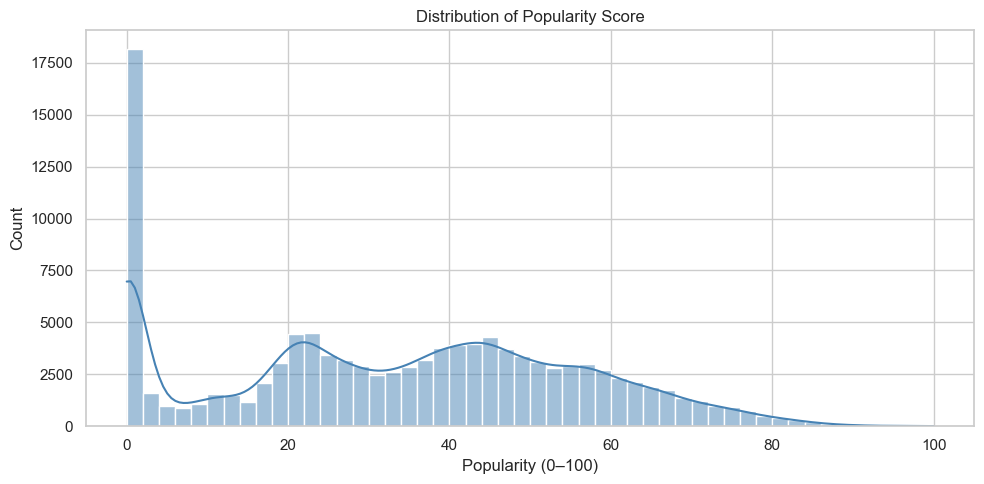

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Popularity Score')
plt.xlabel('Popularity (0–100)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Interpretation | Popularity Distribution

The popularity score is **heavily right-skewed**, with a large spike near 0. This tells us that most tracks in the dataset are relatively unknown or have very low engagement on Spotify. Only a small portion of tracks reach high popularity scores (above 60–70).

This is important because it means our model will see far more examples of "unpopular" songs than popular ones. We may need to account for this imbalance during preprocessing or modeling.

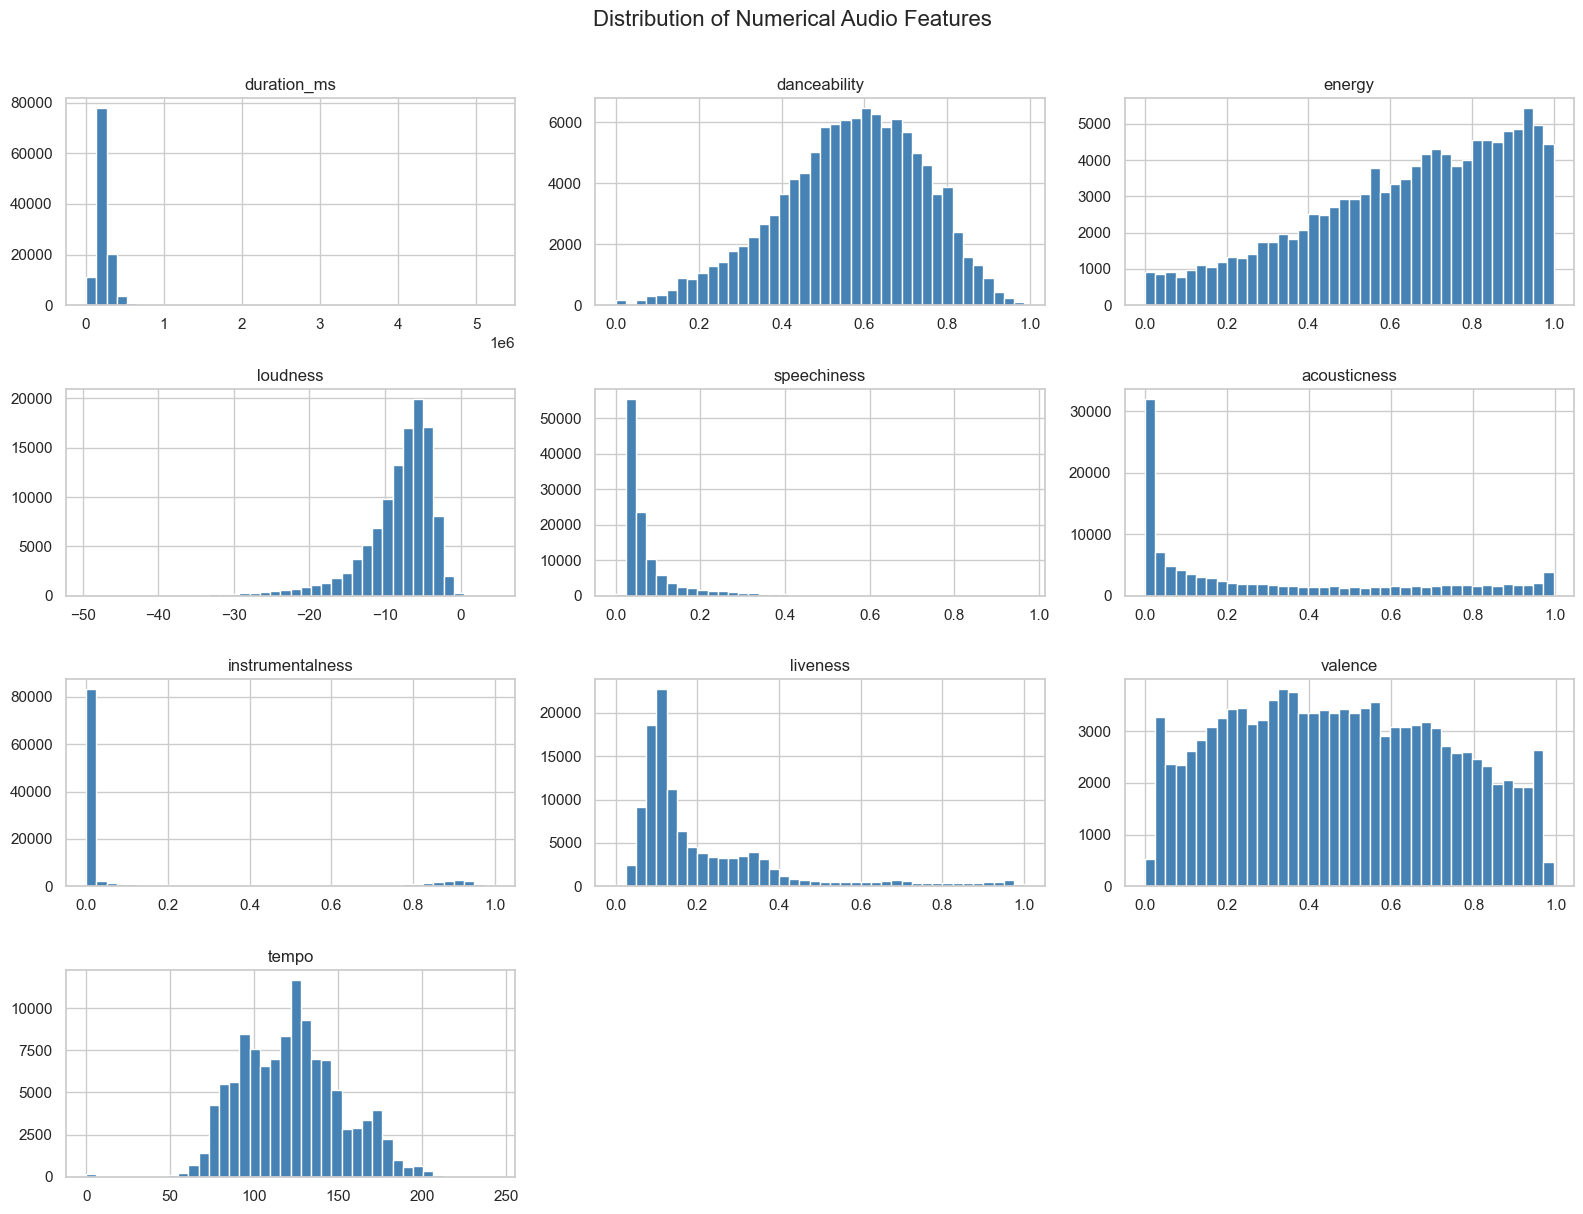

In [11]:
num_cols = ['duration_ms', 'danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

df[num_cols].hist(bins=40, figsize=(16, 12), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Numerical Audio Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation | Audio Feature Distributions

- **Danceability & Valence** are fairly normally distributed, suggesting most songs have moderate danceability and mood.
- **Energy** is slightly left-skewed, many tracks tend to be on the higher energy side.
- **Instrumentalness, Speechiness, and Acousticness** are heavily right-skewed, meaning most tracks are non-instrumental, non-spoken-word, and non-acoustic. These columns may need transformation later.
- **Loudness** is left-skewed with values mostly between -20 and 0 dB, which is typical for mastered audio.
- **Duration** has a long right tail, a few tracks are extremely long, which may be outliers.

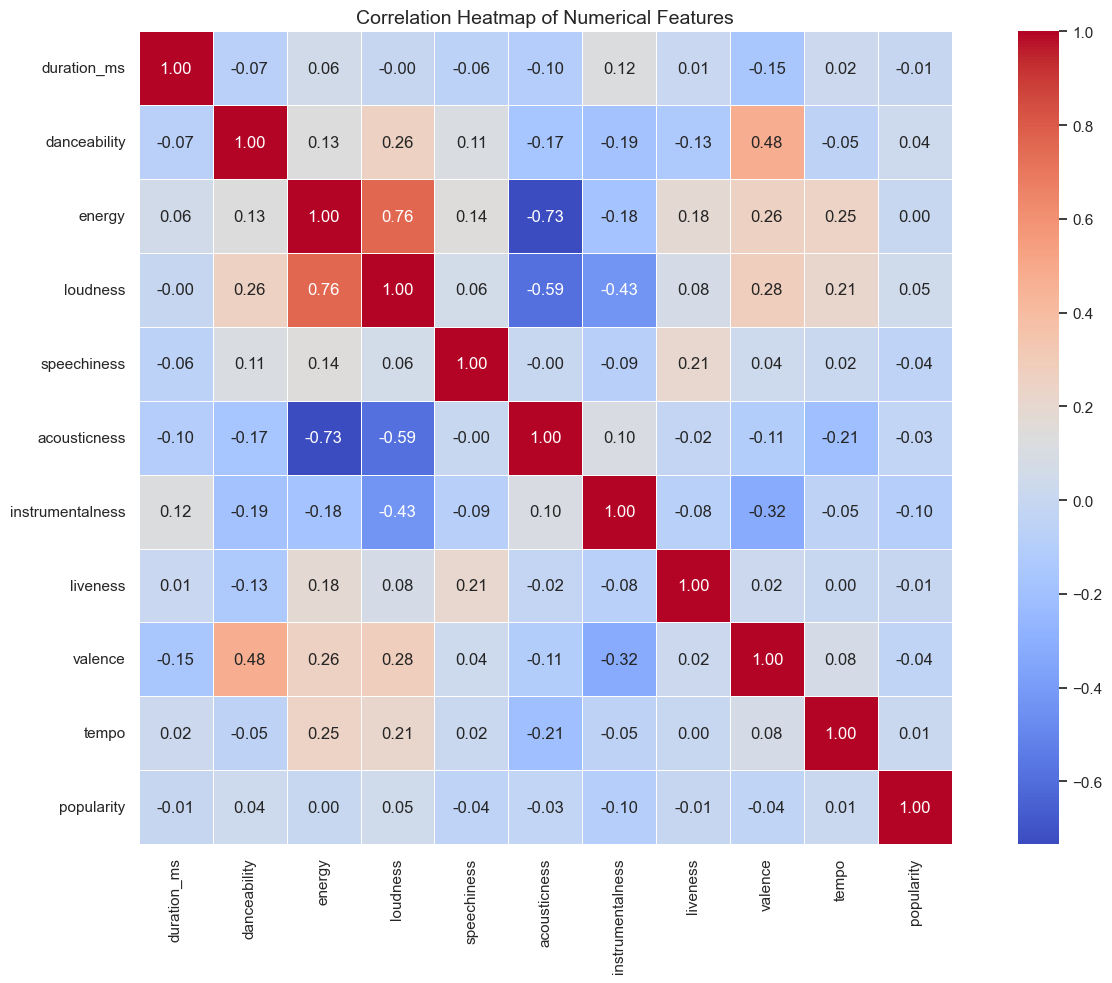

In [12]:
plt.figure(figsize=(14, 10))
corr_matrix = df[num_cols + ['popularity']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation | Correlation Heatmap

- **Loudness** and **energy** have a moderate positive correlation with each other, which makes sense, louder songs tend to feel more energetic.
- **Acousticness** and **energy** are negatively correlated, acoustic songs are generally less intense.
- **Popularity** does not have a very strong linear correlation with any single feature, which suggests that a simple linear model may struggle and that **feature engineering and ensemble methods** will be important.
- **Instrumentalness** has a slight negative relationship with popularity, purely instrumental tracks tend to be less popular on Spotify.

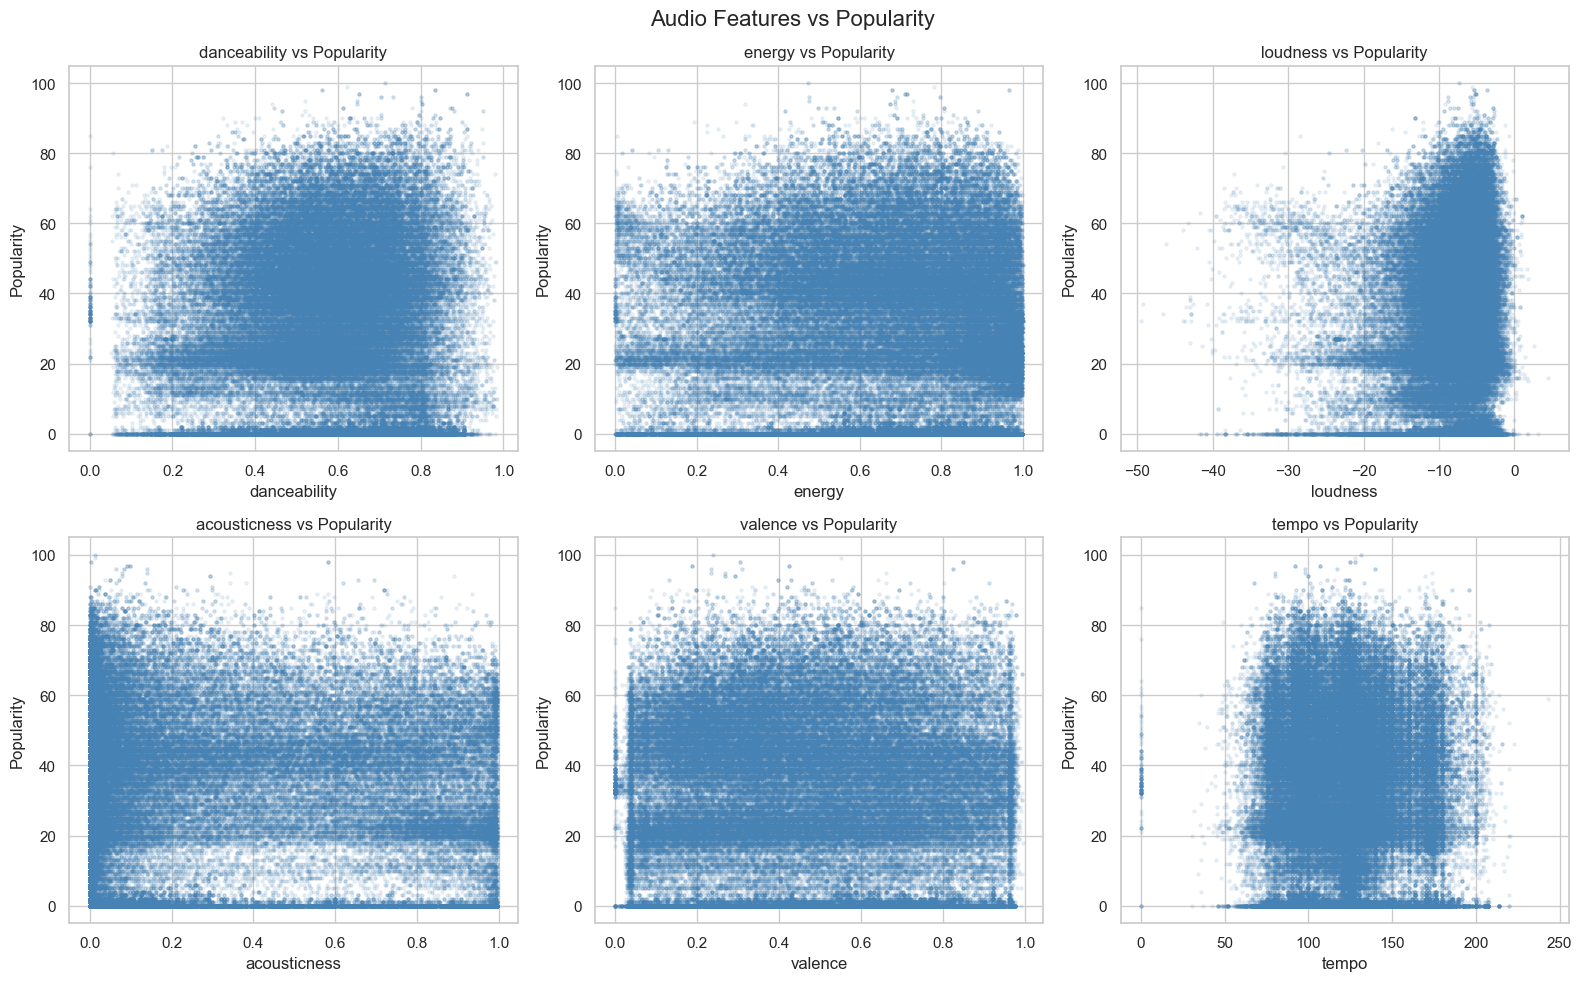

In [13]:
features_to_plot = ['danceability', 'energy', 'loudness', 'acousticness', 'valence', 'tempo']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    axes[i].scatter(df[feat], df['popularity'], alpha=0.1, color='steelblue', s=5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Popularity')
    axes[i].set_title(f'{feat} vs Popularity')

plt.suptitle('Audio Features vs Popularity', fontsize=16)
plt.tight_layout()
plt.show()

### Interpretation | Feature vs Popularity Scatter Plots

- Most plots show a **wide spread of popularity values** across all feature ranges, confirming that no single feature alone is a strong predictor.
- **Loudness** shows a slight upward trend, louder (closer to 0 dB) songs tend to score slightly higher in popularity.
- **Acousticness** shows a slight downward trend, highly acoustic tracks tend to be less popular on Spotify's general audience.
- The vertical cluster near popularity = 0 reinforces what we saw in the distribution, many tracks are simply not popular at all regardless of their audio features.

We have to use **multiple features together** in a model rather than relying on any one alone.

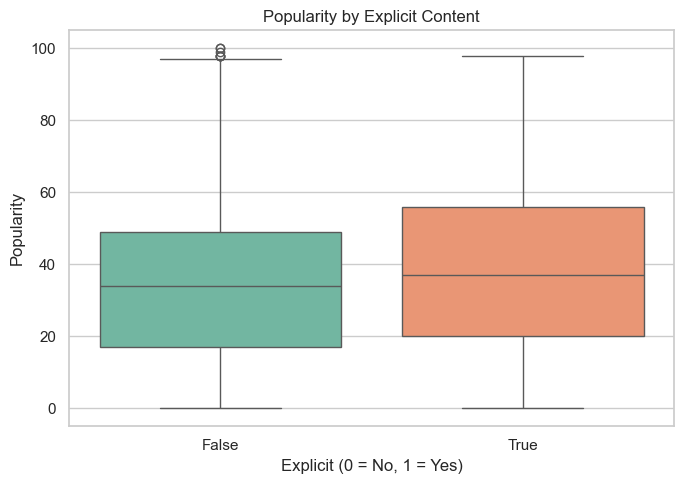

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='explicit', y='popularity', data=df, palette='Set2')
plt.title('Popularity by Explicit Content')
plt.xlabel('Explicit (0 = No, 1 = Yes)')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

### Interpretation | Explicit Content vs Popularity

Tracks marked as **explicit** tend to have a slightly higher median popularity compared to non-explicit tracks. This could reflect genre trends | explicit content is common in hip-hop and rap, which are among the most-streamed genres on Spotify.

This confirms that `explicit` is a meaningful categorical feature worth keeping in our model.

## 3. Data Cleaning & Preprocessing

- Drop columns that are not useful for prediction
- Handle the `time_signature` and `key` columns
- Encode categorical variables
- Check and fix data types

In [15]:
# These are identifier/metadata columns — not useful as model features
cols_to_drop = ['Unnamed: 0', 'track_id', 'track_name', 'album_name', 'artists']

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


### Why Drop These Columns?

Columns like `track_id`, `track_name`, `album_name`, and `artists` are **identifiers**, they uniquely label a track but carry no generalizable signal for predicting popularity. Including them would be like trying to predict a student's grade based on their student ID number.

The `Unnamed: 0` column is just a leftover index.

In [16]:
# let's make sure it's integer
df['explicit'] = df['explicit'].astype(int)
print(df['explicit'].value_counts())

explicit
0    104252
1      9747
Name: count, dtype: int64


In [17]:
print("Number of unique genres:", df['track_genre'].nunique())
print(df['track_genre'].value_counts().head(10))

Number of unique genres: 114
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64


### Handling `track_genre`

The dataset has **114 unique genres**. We can't just drop this column because genre is likely one of the strongest signals for popularity (pop and hip-hop tracks tend to score much higher than niche genres for examplew).

However, one-hot encoding 114 genres would create too many columns. Instead, we'll use **Label Encoding** for now and revisit this in feature engineering with a smarter approach, encoding genres by their **mean popularity**.

In [18]:
# Mean target encoding for track_genre
genre_mean_popularity = df.groupby('track_genre')['popularity'].mean()
df['genre_encoded'] = df['track_genre'].map(genre_mean_popularity)

# Drop original genre column
df.drop(columns=['track_genre'], inplace=True)

print("Genre mean encoding done.")
df[['genre_encoded']].describe()

Genre mean encoding done.


,genre_encoded
count,113999.000000
mean,33.238827
std,11.246073
min,2.210000
25%,25.676000
50%,34.739000
75%,41.143000
max,59.283000


### Why Mean Target Encoding?

Mean target encoding replaces each genre with the **average popularity of tracks in that genre**. Think of it like replacing a student's school name with that school's average GPA, it preserves meaningful information in a single numeric column instead of exploding into 114 binary columns.

This is a powerful technique but must be applied carefully to avoid **data leakage**, we're applying it on the full dataset here for simplicity, but in a industry practice it should be fit only on training data.

## 4. Outlier Detection & Treatment

We'll use the **IQR (Interquartile Range)** method to detect and cap outliers (Winsorization) in numerical features.

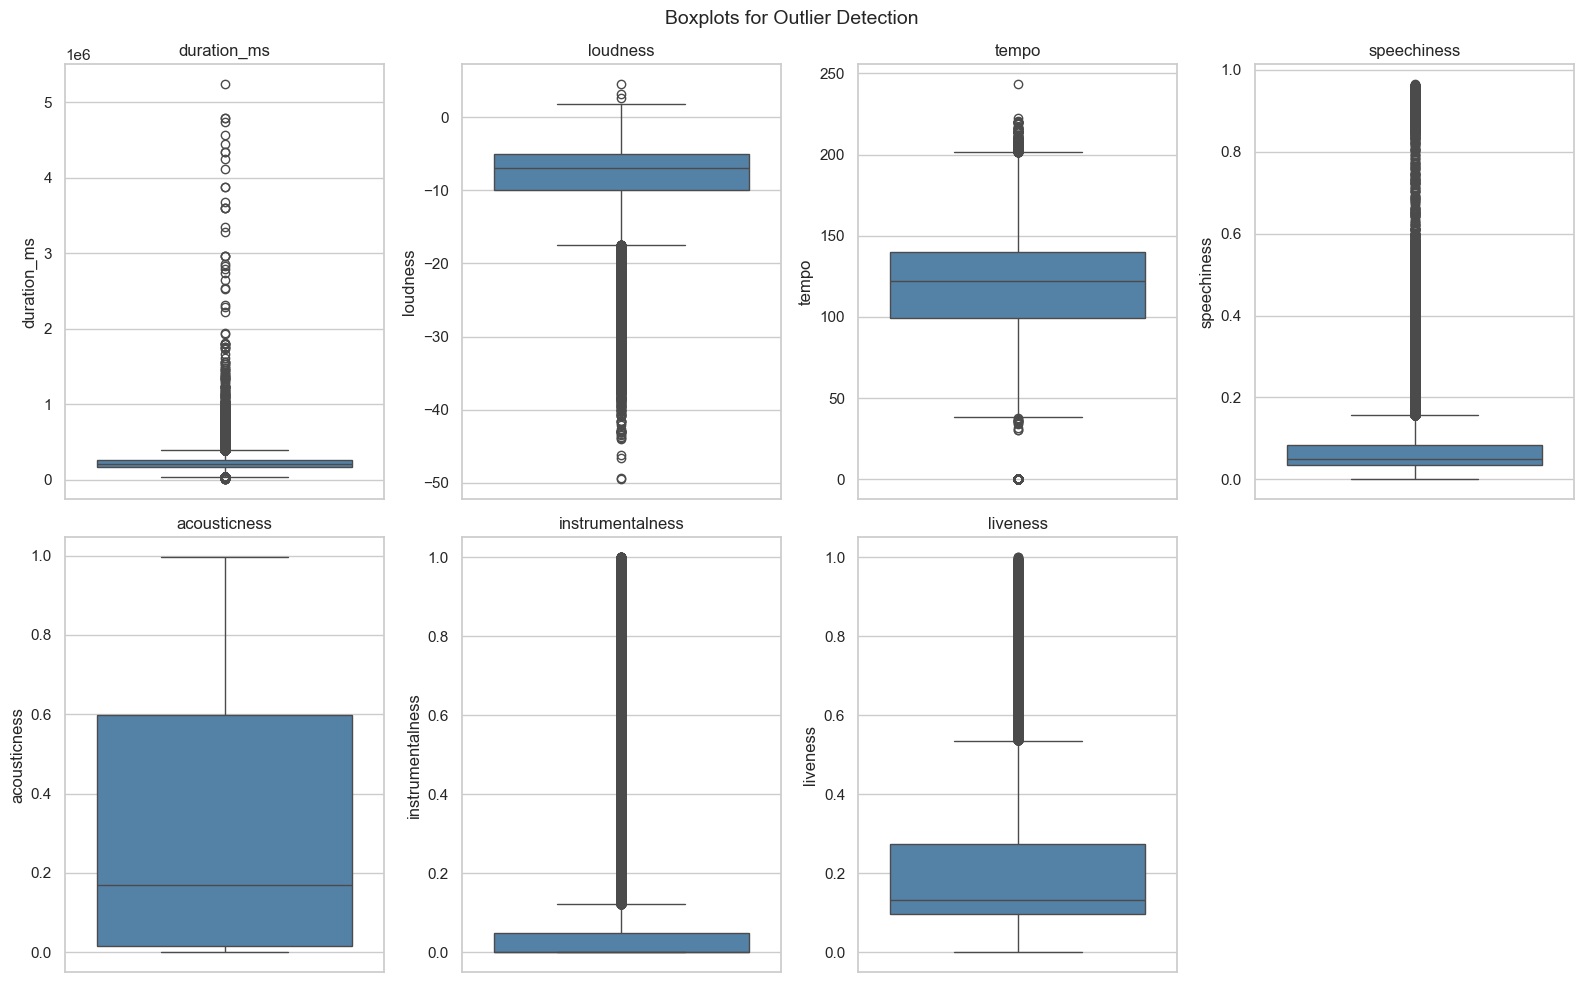

In [19]:
outlier_cols = ['duration_ms', 'loudness', 'tempo', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness']

plt.figure(figsize=(16, 10))
for i, col in enumerate(outlier_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col], color='steelblue')
    plt.title(col)

plt.suptitle('Boxplots for Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation | Outlier Detection

- **duration_ms** has extreme values, some tracks are several hours long, which are likely podcasts or misclassified entries.
- **speechiness** and **instrumentalness** have many high-end outliers, consistent with their skewed distributions we saw earlier.
- **liveness** also shows some extreme values.

We will use **IQR-based capping (Winsorization)** to treat these, instead of deleting outlier rows (which loses data), we clip them to the upper and lower fence values. This is like trimming the edges of a photo instead of throwing it away.

In [20]:
def cap_outliers_iqr(dataframe, columns):
    df_capped = dataframe.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    return df_capped

df = cap_outliers_iqr(df, outlier_cols)
print("Outlier capping applied.")
df[outlier_cols].describe()

Outlier capping applied.


,duration_ms,loudness,tempo,speechiness,acousticness,instrumentalness,liveness
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,222505.179151,-7.942236,122.181902,0.067183,0.314907,0.030945,0.196586
std,73135.840733,4.012151,29.745179,0.042496,0.332522,0.051007,0.140734
min,42906.000000,-17.528000,37.939750,0.000000,0.000000,0.000000,0.000000
25%,174066.000000,-10.013000,99.218500,0.035900,0.016900,0.000000,0.098000
50%,212906.000000,-7.004000,122.017000,0.048900,0.169000,0.000042,0.132000
75%,261506.000000,-5.003000,140.071000,0.084500,0.597500,0.049000,0.273000
max,392666.000000,2.512000,201.349750,0.157400,0.996000,0.122500,0.535500


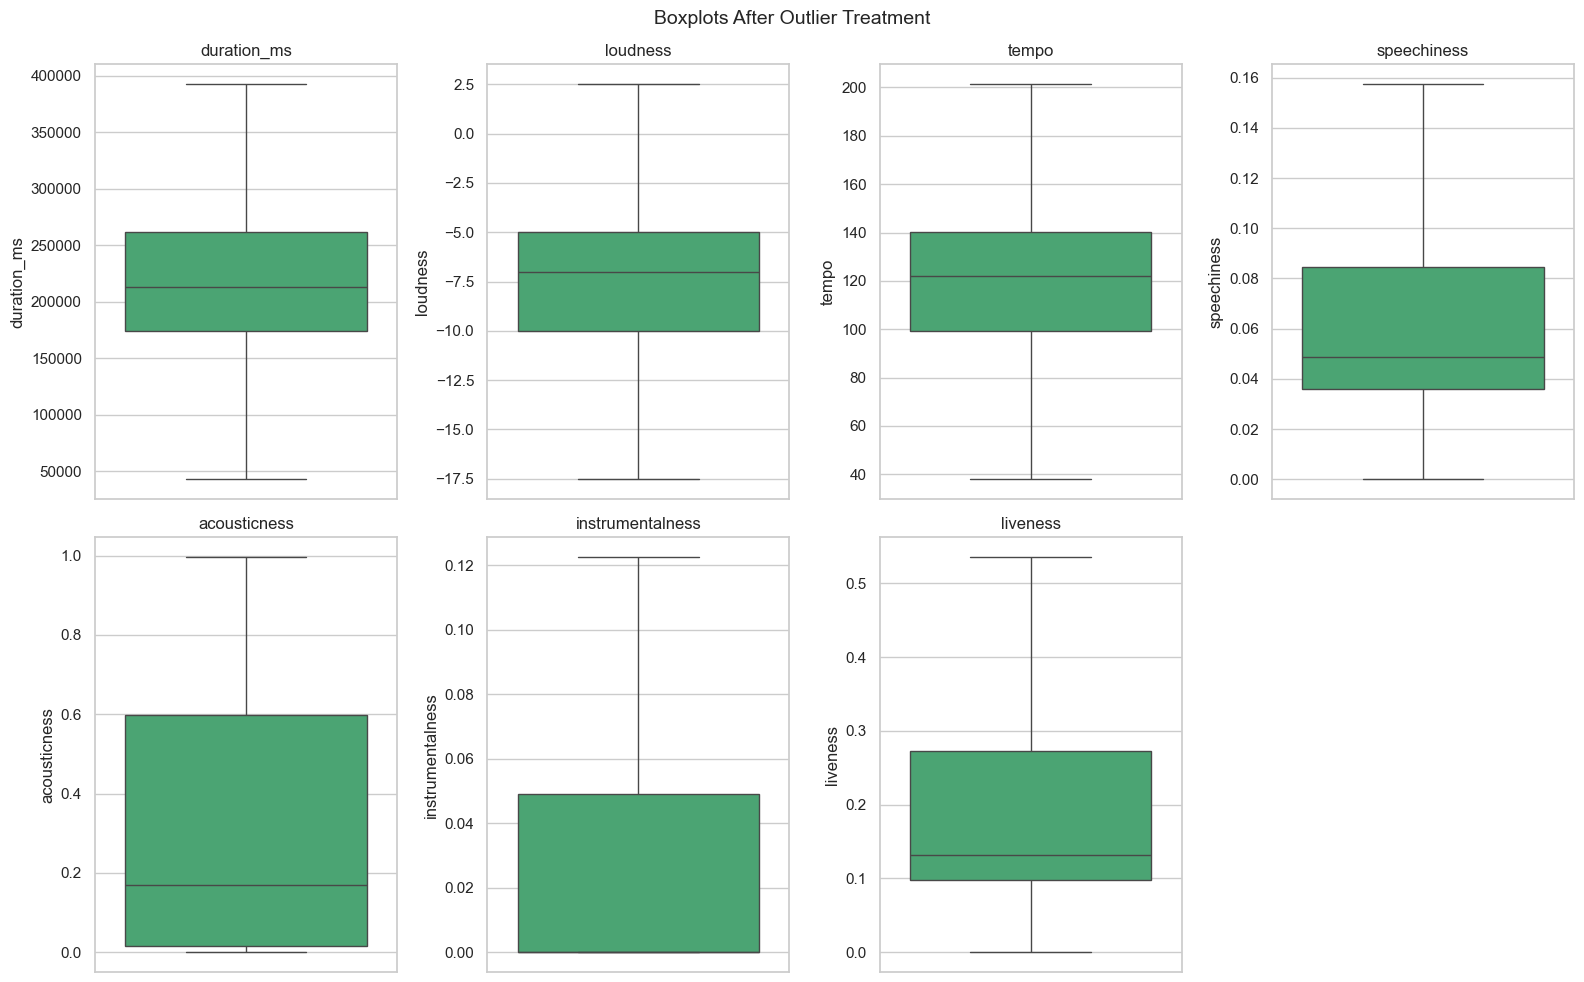

In [21]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(outlier_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col], color='mediumseagreen')
    plt.title(col)

plt.suptitle('Boxplots After Outlier Treatment', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation | After Outlier Treatment

After applying IQR capping, the extreme values have been brought within a reasonable range. The boxplots now show much cleaner distributions with fewer extreme points. This will help our regression models train more stably without being pulled toward extreme values.

## 5. Feature Engineering

We'll create several new features based on domain knowledge about music and audio characteristics.

In [22]:
# Energy-to-Acousticness Ratio - high energy + low acoustic = likely mainstream
df['energy_acoustic_ratio'] = df['energy'] / (df['acousticness'] + 0.000001)

# Dance-Valence Score - upbeat danceable songs tend to be more popular
df['dance_valence'] = df['danceability'] * df['valence']

# Loudness normalized (loudness is negative, flip it)
df['loudness_norm'] = df['loudness'] * -1

# Duration in minutes instead of milliseconds (more interpretable and closer to human perception)
df['duration_min'] = df['duration_ms'] / 60000

# Drop original duration_ms now that we have duration_min
df.drop(columns=['duration_ms'], inplace=True)

print("New features created:")
print(['energy_acoustic_ratio', 'dance_valence', 'loudness_norm', 'duration_min'])
df.head()

New features created:
['energy_acoustic_ratio', 'dance_valence', 'loudness_norm', 'duration_min']


,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre_encoded,energy_acoustic_ratio,dance_valence,loudness_norm,duration_min
0,73,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,42.483,14.316326,0.483340,6.746,3.844433
1,55,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,42.483,0.179653,0.112140,17.235,2.493500
2,57,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,42.483,1.709516,0.052560,9.734,3.513767
3,71,0,0.266,0.0596,0,-17.528,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,42.483,0.065856,0.038038,17.528,3.365550
4,82,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,42.483,0.944561,0.103206,9.681,3.314217


### Interpretation | Engineered Features

- **energy_acoustic_ratio**: Captures how "electric" vs "raw" a track feels. Mainstream pop and EDM tracks score high here.
- **dance_valence**: Combines danceability and positivity/happy, danceable tracks are often crowd favorites.
- **loudness_norm**: Flips loudness to a positive scale (since original values are negative dB). Easier to interpret as "volume level."
- **duration_min**: Converts milliseconds to minutes for readability. Extremely short or long tracks may behave differently in terms of popularity.

These features give the model **richer combinations** to learn from, rather than treating each audio dimension in isolation.

In [23]:
print("Final shape:", df.shape)
print("\nFinal columns:")
print(df.columns.tolist())
print("\nAny remaining nulls:")
print(df.isnull().sum().sum())

Final shape: (113999, 19)

Final columns:
['popularity', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'genre_encoded', 'energy_acoustic_ratio', 'dance_valence', 'loudness_norm', 'duration_min']

Any remaining nulls:
0


**Missing values:** 0  
**Target variable:** `popularity`

## 6. Model Building & Evaluation

We will train and compare:
- **Linear Regression** - simple baseline
- **Ridge Regression** - linear with regularization to reduce overfitting
- **Lasso Regression** - linear with feature selection built in
- **Random Forest Regressor** - collection of decision trees
- **Gradient Boosting Regressor** - trees that learn from each other's mistakes

Each model will be evaluated using:
- **MAE** (Mean Absolute Error) - average prediction error in popularity points
- **RMSE** (Root Mean Squared Error) - penalizes large errors more heavily
- **R²** (R-Squared) - how much of the variance in popularity our model explains

After evaluation **Random Forest** emerged as the best model across all three metrics.

In [24]:
X = df.drop(columns=['popularity'])
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (91199, 18)
Test set size: (22800, 18)


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Why Scale Features?

Some of our features like `tempo` (0–250) and `loudness_norm` (0–60) are on very different scales compared to features like `danceability` (0–1). Without scaling, models like Ridge and Lasso would unfairly weight larger-scale features.

Scaling standardizes all features to have **mean = 0 and standard deviation = 1**, like converting all measurements to the same unit before comparing them. Note: tree-based models like Random Forest don't require scaling, but it doesn't hurt them either.

In [26]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"{'='*40}")
    
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'object': model, 'predictions': y_pred}

### Linear Regression

Our baseline model. It assumes popularity is a straight-line combination of all features. Simple, fast, and interpretable, but likely too simple for this dataset given the weak linear correlations we saw in EDA.

In [27]:
lr_result = evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train_scaled, X_test_scaled,
    y_train, y_test
)


Model: Linear Regression
  MAE  : 14.0677
  RMSE : 19.1185
  R²   : 0.2632


### Ridge & Lasso Regression

Both are regularized versions of Linear Regression.

- **Ridge** adds a penalty for large coefficients, like keeping a budget limit on how much each feature can influence the prediction.
- **Lasso** goes further and can shrink some coefficients to exactly zero, effectively removing weak features from the model.

In [28]:
ridge_result = evaluate_model(
    "Ridge Regression",
    Ridge(alpha=1.0),
    X_train_scaled, X_test_scaled,
    y_train, y_test
)


Model: Ridge Regression
  MAE  : 14.0677
  RMSE : 19.1185
  R²   : 0.2632


In [29]:
lasso_result = evaluate_model(
    "Lasso Regression",
    Lasso(alpha=0.1),
    X_train_scaled, X_test_scaled,
    y_train, y_test
)


Model: Lasso Regression
  MAE  : 14.0815
  RMSE : 19.1204
  R²   : 0.2631


### Random Forest Regressor

Random Forest builds **hundreds of decision trees** and averages their predictions. Each tree is trained on a random subset of data and features, like asking 100 different music analysts their opinion and averaging the result. This reduces overfitting and handles non-linear relationships well.

In [30]:
rf_result = evaluate_model(
    "Random Forest",
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_scaled, X_test_scaled,
    y_train, y_test
)


Model: Random Forest
  MAE  : 10.7518
  RMSE : 15.9073
  R²   : 0.4899


### Gradient Boosting Regressor

Gradient Boosting builds trees **sequentially**, each new tree focuses on correcting the errors made by the previous one. It's like a student reviewing only their wrong answers after each practice test, getting better with each round.

In [31]:
gb_result = evaluate_model(
    "Gradient Boosting",
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    X_train_scaled, X_test_scaled,
    y_train, y_test
)


Model: Gradient Boosting
  MAE  : 13.9015
  RMSE : 18.8320
  R²   : 0.2851


## 7. Model Comparison

Let's compare all models side by side to identify the best performer.

In [32]:
results = [lr_result, ridge_result, lasso_result, rf_result, gb_result]
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'object' and k != 'predictions'} for r in results])
results_df = results_df.sort_values('RMSE')
print(results_df.to_string(index=False))

            Model       MAE      RMSE       R2
    Random Forest 10.751803 15.907342 0.489924
Gradient Boosting 13.901510 18.831970 0.285123
Linear Regression 14.067668 19.118455 0.263207
 Ridge Regression 14.067691 19.118455 0.263207
 Lasso Regression 14.081547 19.120372 0.263059


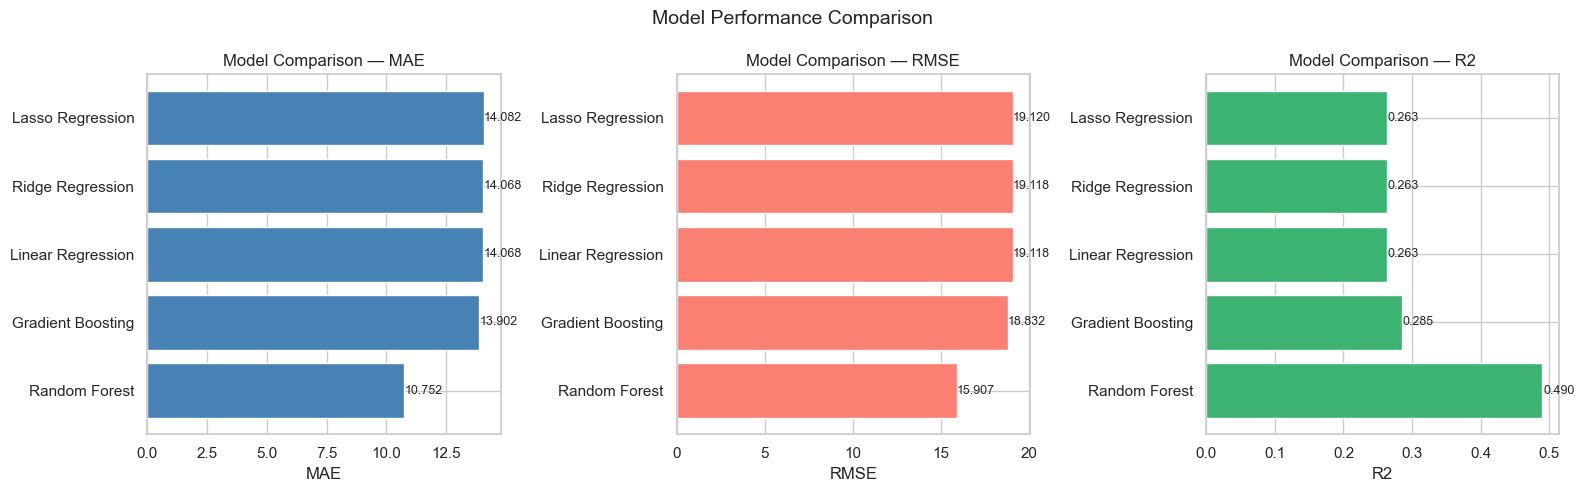

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['MAE', 'RMSE', 'R2']
colors = ['steelblue', 'salmon', 'mediumseagreen']

for i, metric in enumerate(metrics):
    axes[i].barh(results_df['Model'], results_df[metric], color=colors[i])
    axes[i].set_title(f'Model Comparison — {metric}')
    axes[i].set_xlabel(metric)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(v + 0.001, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation — Model Comparison

From the table and bar charts above, we can clearly rank the models:

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Random Forest | 10.75 | 15.91 | 0.49 |
| Gradient Boosting | 13.90 | 18.83 | 0.29 |
| Linear Regression | 14.07 | 19.12 | 0.26 |
| Ridge Regression | 14.07 | 19.12 | 0.26 |
| Lasso Regression | 14.08 | 19.12 | 0.26 |

**Random Forest outperforms all other models** across every metric — lowest MAE, lowest RMSE, and highest R².

Key observations:
- **Linear, Ridge, and Lasso** perform nearly identically and serve as our baseline. Their high RMSE and low R² confirm that popularity does not have a simple linear relationship with audio features.
- **Gradient Boosting** improves slightly over linear models but underperforms Random Forest. This is likely because popularity is a noisy target, it is heavily influenced by factors outside our dataset like artist fame and social media trends. Gradient Boosting's sequential error correction ends up chasing noise rather than real patterns.
- **Random Forest** handles this noise best by averaging 100 independent trees. Random errors across trees cancel each other out, producing more stable and accurate predictions.

We select **Random Forest** as our final model for deployment.

## 8. Residual Analysis of Best Model

Before saving our model, let's inspect its residuals, the difference between predicted and actual popularity. A well-behaved model should have residuals that are **randomly scattered around zero**, like noise with no pattern.

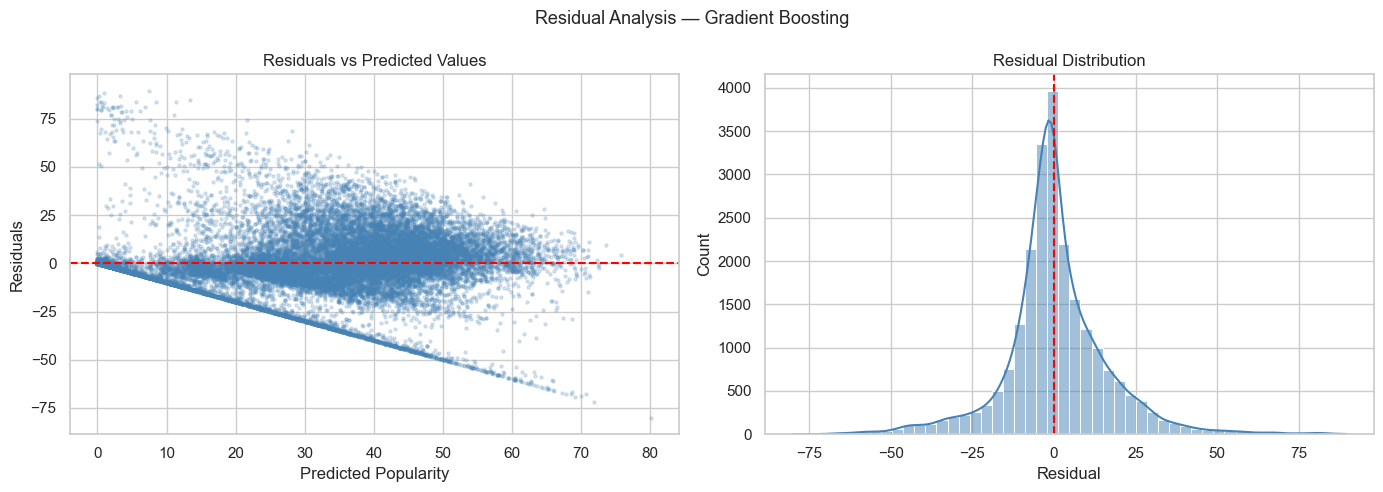

In [34]:
best_result = rf_result
y_pred_best = best_result['predictions']
residuals = y_test - y_pred_best

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_best, residuals, alpha=0.2, color='steelblue', s=5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Popularity')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Residual Distribution')

plt.suptitle('Residual Analysis — Gradient Boosting', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation | Residual Analysis

- The residuals are **approximately centered around zero**, which means our model is not systematically over or under-predicting. Though it might be showing a slight tendency for the prediction to be too positive/high.
- The thick downward line in the scatterplot is actually all the tracks that has the popularity 0 but the model keeps predicting a positive value for them. This is a clear limitation.

## 9. Feature Importance

Let's see which features the Random Forest model found most useful. This is like asking the model "what did you pay the most attention to?"

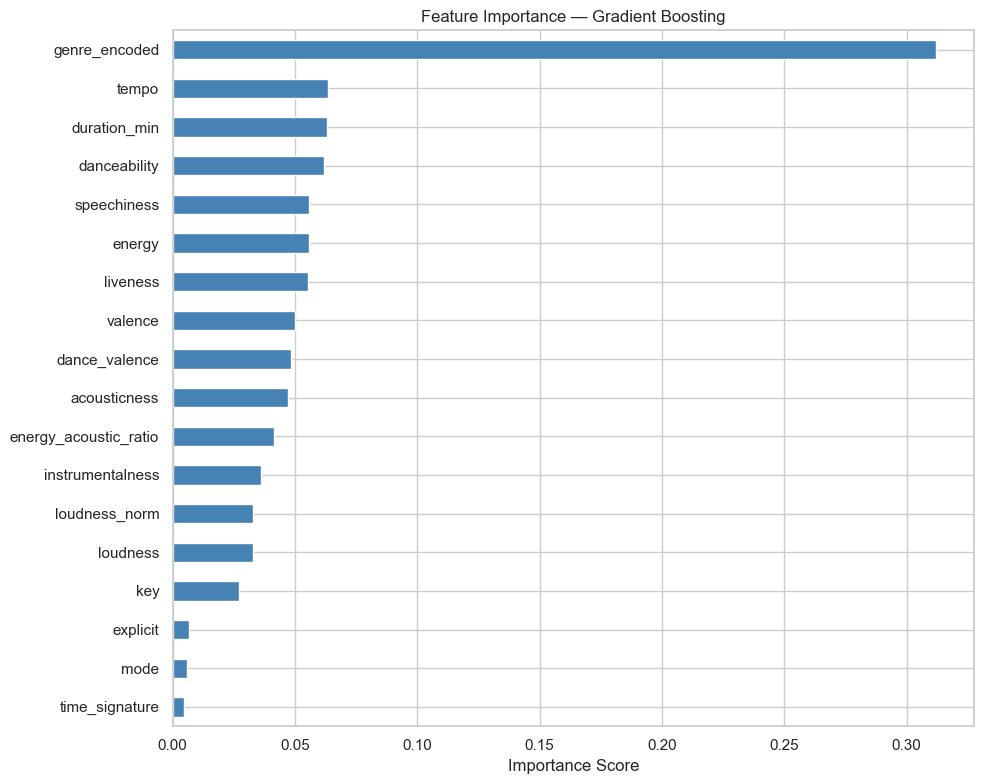

In [35]:
best_model_obj = best_result['object']

feature_importance = pd.Series(
    best_model_obj.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feature_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Interpretation — Feature Importance

- **genre_encoded** (mean popularity per genre) is the strongest predictor, confirming that genre is a major driver of how popular a track becomes on Spotify.
- The other features are close to each other but explicit, mode, and time_signature proves to not have much impact to determining a track's popularit.

## 10. Saving the Best Model

We'll save the trained Random Forest model and the scaler using `pickle` so they can be loaded directly into our Django web application for deployment.

In [36]:
import pickle

# Save the model
with open('spotify_popularity_model.pkl', 'wb') as f:
    pickle.dump(best_result['object'], f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the feature column names (needed for Django app input alignment)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Model, scaler, and feature columns saved successfully.")
print("Files: spotify_popularity_model.pkl | scaler.pkl | feature_columns.pkl")

Model, scaler, and feature columns saved successfully.
Files: spotify_popularity_model.pkl | scaler.pkl | feature_columns.pkl


## Summary

| Step | Action |
|------|--------|
| Data Loading | Loaded 114,000+ Spotify tracks |
| EDA | Analyzed distributions, correlations, and feature relationships |
| Cleaning | Dropped identifiers and nulls
| Encoding | Applied mean target encoding for genre |
| Outliers | Detected and capped using IQR Winsorization |
| Feature Engineering | Created 4 new features from domain knowledge |
| Modeling | Trained 5 regression models |
| Best Model | Random Forest Regressor |
| Evaluation | MAE, RMSE, R² computed and compared |
| Deployment | Model saved as `.pkl` for Django integration |

---

The **Random Forest Regressor** was selected as the final model based on its superior performance across all three metrics. The model will be deployed as a simple web application where users can input audio features and receive a predicted popularity score.